In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering,KMeans,DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv("/Users/nurdauletaldibek/Desktop/ML course/kaggle problems/Сегментация клиентов/Mall_Customers.csv")

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


/var/folders/w3/lhfrksk14cq_tgn0vkzfrbgh0000gn/T/ipykernel_54880/3275111431.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


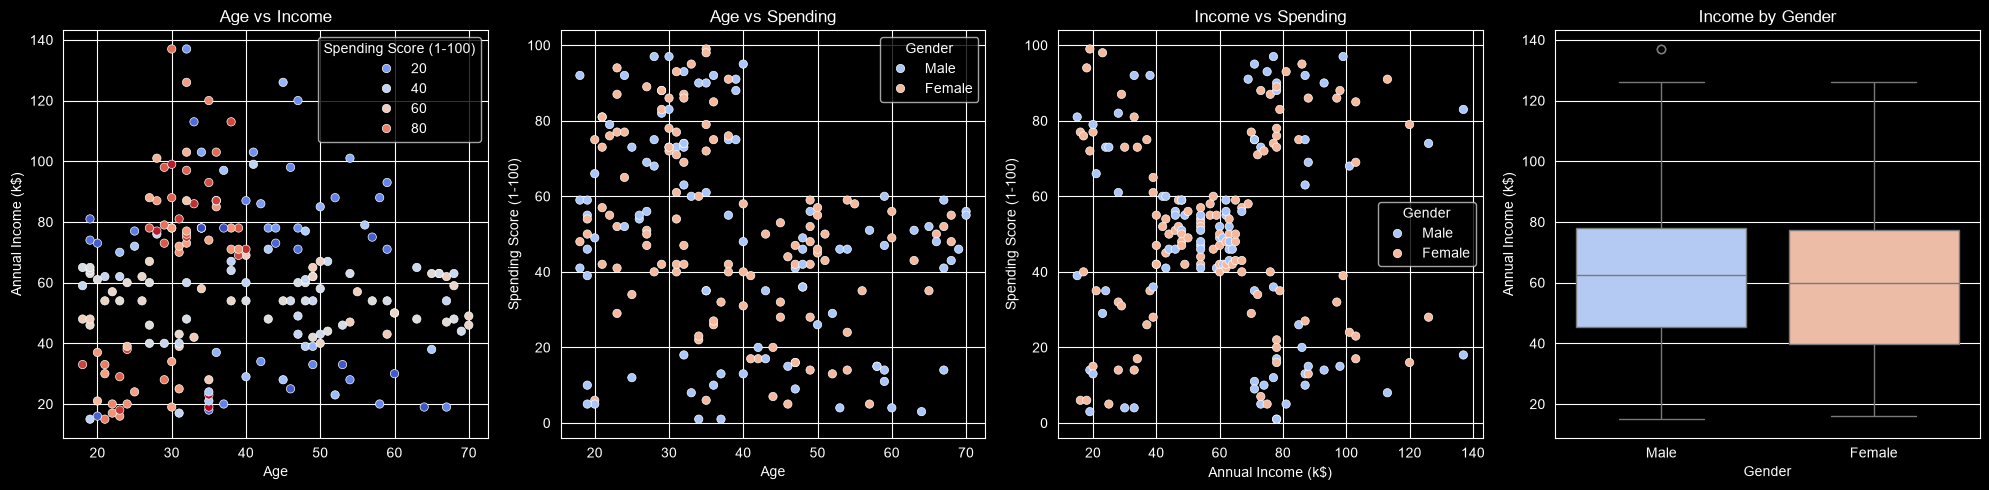

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаем сетку: 1 строка, 4 колонки. figsize задает (ширину, высоту) в дюймах
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 2. Строим график 1 (на первом месте - axes[0])
sns.scatterplot(
    data=df, x='Age', y='Annual Income (k$)',
    hue='Spending Score (1-100)', palette='coolwarm', ax=axes[0]
)
axes[0].set_title('Age vs Income') # Заголовок для первого графика

# 3. Строим график 2 (на втором месте - axes[1])
sns.scatterplot(
    data=df, x='Age', y='Spending Score (1-100)',
    hue='Gender', palette='coolwarm', ax=axes[1]
)
axes[1].set_title('Age vs Spending')

# 4. Строим график 3 (на третьем месте - axes[2])
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Gender', palette='coolwarm', ax=axes[2]
)
axes[2].set_title('Income vs Spending')

# 5. Строим график 4 (на четвертом месте - axes[3])
# Вместо scatter можно взять boxplot, чтобы посмотреть распределение доходов по полу
sns.boxplot(
    data=df, x='Gender', y='Annual Income (k$)',
    palette='coolwarm', ax=axes[3]
)
axes[3].set_title('Income by Gender')

# Автоматически настраивает расстояния, чтобы подписи не наезжали друг на друга
plt.tight_layout()
plt.show()


(array([24., 22., 28., 38., 30., 36.,  8.,  6.,  4.,  4.]),
 array([ 15. ,  27.2,  39.4,  51.6,  63.8,  76. ,  88.2, 100.4, 112.6,
        124.8, 137. ]),
 <BarContainer object of 10 artists>)

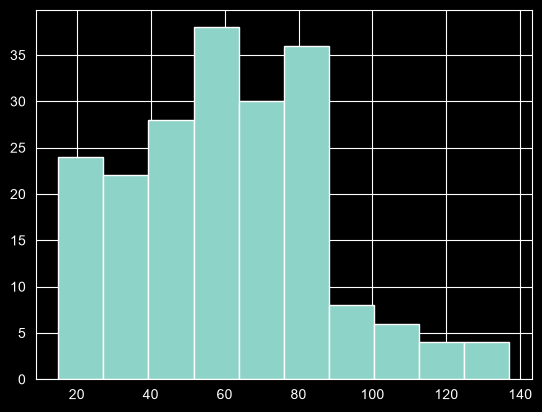

In [5]:
plt.hist(
    df['Annual Income (k$)'],

)

In [6]:
cluster_features = ['Annual Income (k$)','Spending Score (1-100)']
df['Gender'] = df["Gender"].map({'Female': 0, 'Male': 1})
need_to_scaler = ['Annual Income (k$)','Spending Score (1-100)',"Age"]
df[need_to_scaler] = StandardScaler().fit_transform(df[need_to_scaler])
X_cluster = df[cluster_features]

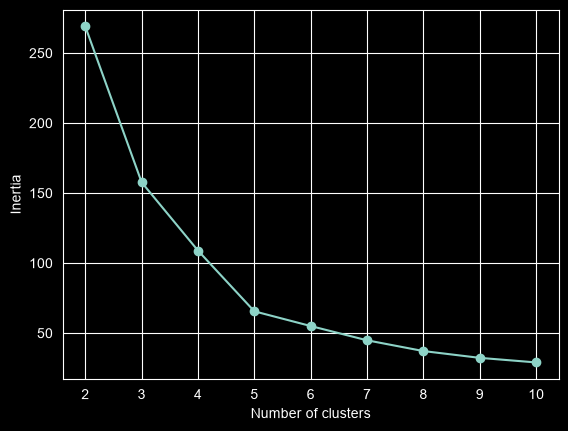

In [7]:
from sklearn.metrics import silhouette_score
k_range = [i for i in range(2,11)]
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=17,n_init=100)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.plot(k_range,inertias,marker = 'o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()



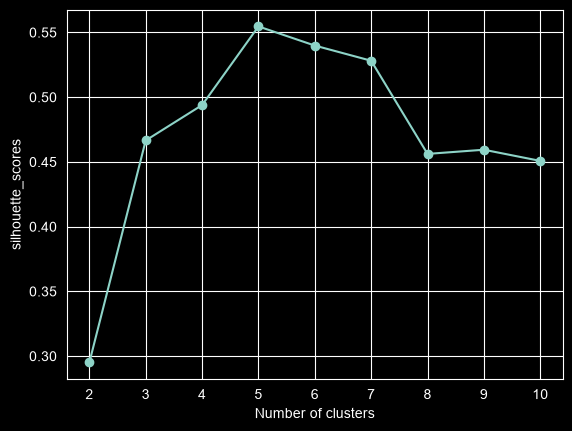

In [8]:
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=17,n_init=100)
    labels = kmeans.fit_predict(X_cluster)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

plt.plot(k_range,silhouette_scores,marker = 'o')
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_scores")
plt.show()

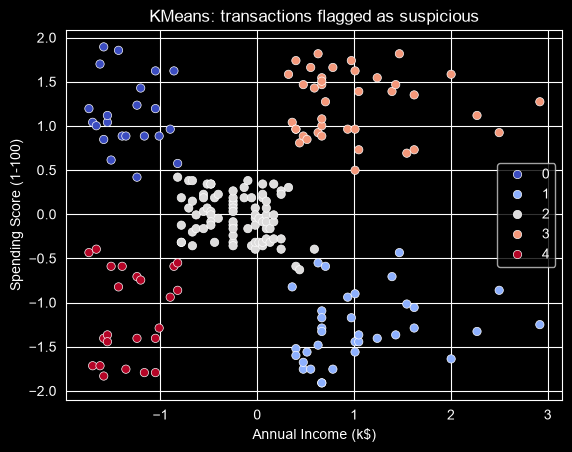

In [9]:
kmeans = KMeans(n_clusters=5, random_state=17,n_init=100)
kmeans_cluster = kmeans.fit_predict(X_cluster)

# 2. Строим график 1 (на первом месте - axes[0])
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=kmeans_cluster,
    palette='coolwarm'
)
plt.title("KMeans: transactions flagged as suspicious")
plt.show()

/opt/anaconda3/envs/yandex_litsey/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


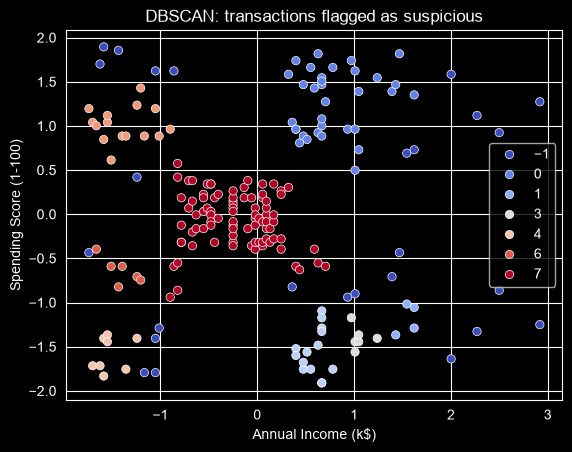

In [17]:
from sklearn.cluster import HDBSCAN   # sklearn ≥ 1.3
import numpy as np

hdb = HDBSCAN(min_cluster_size=4)
labels = hdb.fit_predict(X_cluster)

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=labels,
    palette='coolwarm'
)
plt.title("DBSCAN: transactions flagged as suspicious")
plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

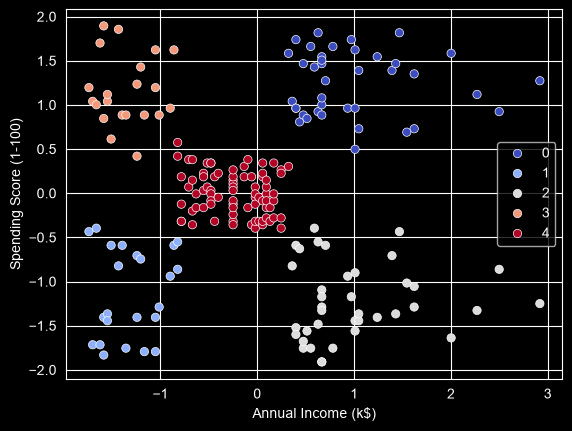

In [24]:
agg_model = AgglomerativeClustering(n_clusters=5, linkage="complete")
agg_labels = agg_model.fit_predict(X_cluster)
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=agg_labels,
    palette='coolwarm'

)

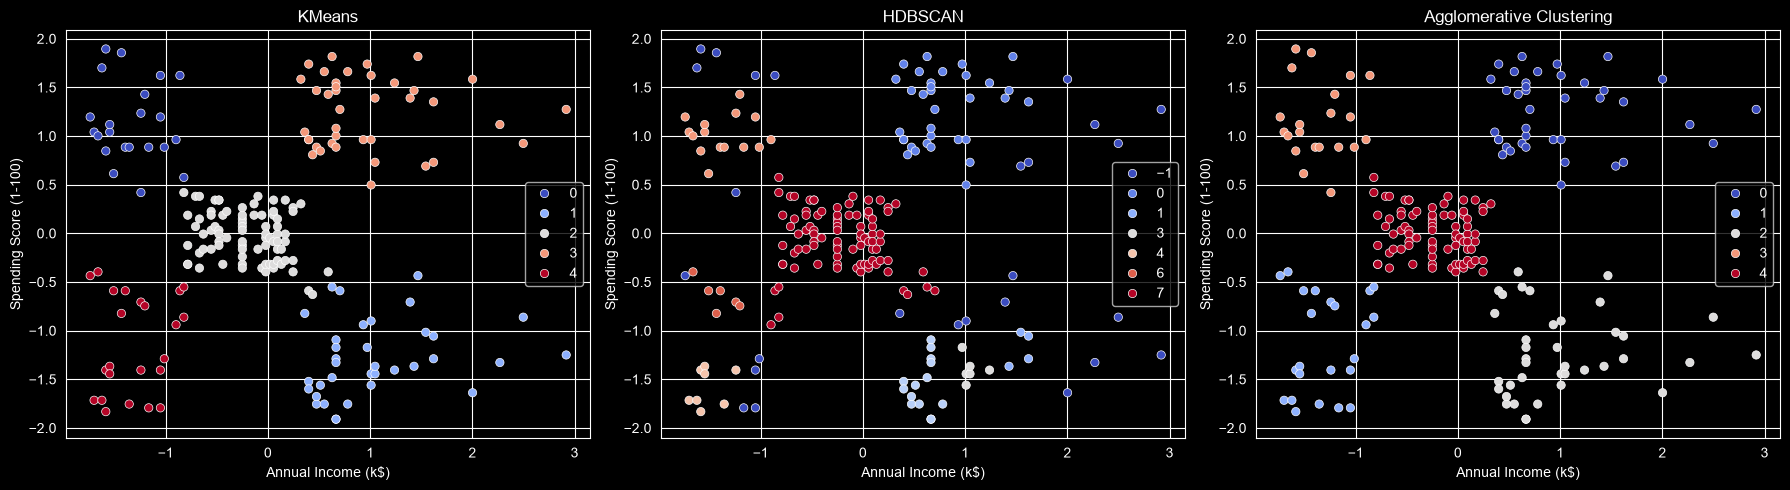

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=kmeans_cluster,
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title("KMeans")

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=labels,
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title("HDBSCAN")

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue=agg_labels,
    palette='coolwarm',
    ax=axes[2]
)
axes[2].set_title("Agglomerative Clustering")

plt.tight_layout()
plt.show()